In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd

# Path to your Drive folder with the CSV exports
folder_path = '/content/drive/MyDrive/Portfolio/'

# Read and combine all CSVs
df_list = []
for filename in sorted(os.listdir(folder_path)):
    if filename.endswith('.csv') and filename.startswith('Export_'):
        date_str = filename.replace('Export_', '').replace('.csv', '')
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        df['Source Date'] = date_str  # Add source date as a new column
        df_list.append(df)

# Concatenate all into a single DataFrame
all_data = pd.concat(df_list, ignore_index=True)
# Exclude rows where the first column contains "Total"
first_col = all_data.columns[0]
all_data = all_data[~all_data[first_col].astype(str).str.contains('Total', case=False, na=False)]


In [ ]:
import numpy as np

# Standardize column names to lowercase and replace spaces with underscores
all_data.columns = all_data.columns.str.strip().str.lower().str.replace(' ', '_')

# Convert source_date to datetime format
all_data['source_date'] = pd.to_datetime(all_data['source_date'])

# Handle 'fecha_promedio_inv' with mixed date formats
# First, try to parse with the explicit 'MM/DD/YYYY' format
parsed_dates_explicit = pd.to_datetime(all_data['fecha_promedio_inv'], format='%m/%d/%Y', errors='coerce')

# Then, for the rows where explicit parsing failed (resulted in NaT),
# try to infer the format from the original string
unparsed_mask = parsed_dates_explicit.isna()
# Ensure to only pass non-NaT values of original column to inferred parsing
parsed_dates_inferred = pd.to_datetime(all_data.loc[unparsed_mask, 'fecha_promedio_inv'], errors='coerce')

# Combine the results: prioritize explicit parsing, then inferred
all_data['fecha_promedio_inv'] = parsed_dates_explicit.fillna(parsed_dates_inferred)

# Recalculate meses_invertido
all_data['meses_invertido'] = (
    (all_data['source_date'].dt.year - all_data['fecha_promedio_inv'].dt.year) * 12
    + (all_data['source_date'].dt.month - all_data['fecha_promedio_inv'].dt.month)
    + 1
)

# Handle cases where fecha_promedio_inv might be after source_date or NaT
all_data.loc[all_data['meses_invertido'] < 1, 'meses_invertido'] = 1
# Convert to integer, coercing errors to NaN and then filling (or dropping later)
all_data['meses_invertido'] = all_data['meses_invertido'].replace([np.inf, -np.inf], np.nan).astype(float).fillna(1).astype(int)

# Update first_col after renaming columns (first_col should now be correct due to early renaming)
first_col = all_data.columns[0]

# Preview the data
all_data.head()

,ticker,tir,cantidad,valuacion,fecha_promedio_inv,meses_invertido,retorno_mensual,inversion,dividendo,div_yield,...,unnamed:_16,unnamed:_17,unnamed:_18,unnamed:_19,vs._curv_hist,sell_flags,unnamed:_20,comment,unnamed:_6,unnamed:_21
0,SUPV,0.16461259222693478,3211.0,4761.978531,2021-04-01,38,8.066017,2890.985823,134.012760,0.046355384873069144,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CEPU,0.10957172896802393,5036.0,5112.670531,2020-02-14,52,6.793447,4025.658466,481.821172,0.11968754320838731,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GGAL,2.1541850047586557,893.0,3153.653192,2023-05-23,13,49.546255,1018.748980,116.476157,0.11433253859211857,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PAMP,0.1677600739350786,680.0,1370.380408,2020-07-10,47,9.562324,1960.280126,0.000000,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,EDN,1.0116091856103913,2309.0,2096.477755,2023-05-23,13,23.267011,1024.382172,0.000000,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Add month field
all_data['month'] = all_data['source_date'].dt.to_period('M')

# Sort by stock + date
all_data = all_data.sort_values(by=[first_col, 'source_date'])

# Group by stock and calculate period-over-period deltas
grouped = all_data.groupby(first_col)

results = []

for stock, group in grouped:
    group = group.sort_values('source_date').copy()
    group['prev_valuation'] = group['valuacion'].shift(1)
    group['prev_invested'] = group['inversion'].shift(1)
    group['prev_sold'] = group['venta'].shift(1)
    group['prev_dividends'] = group['dividendo'].shift(1)

    # Calculate period changes
    group['delta_invested'] = group['inversion'] - group['prev_invested']
    group['delta_sold'] = group['venta'] - group['prev_sold']
    group['delta_dividends'] = group['dividendo'] - group['prev_dividends']
    group['delta_valuation'] = group['valuacion'] - group['prev_valuation']

    # Calculate earning this period
    group['earning'] = (
        group['delta_valuation']
        - group['delta_invested']
        + group['delta_sold']
        + group['delta_dividends']
    )

    results.append(group)

# Combine all stock-level earnings into a single DataFrame
earnings_df = pd.concat(results)

# Optional: group by month for total earnings
monthly_total = earnings_df.groupby(earnings_df['source_date'].dt.to_period('M'))['earning'].sum().reset_index()
monthly_total.columns = ['month', 'total_earning']


In [ ]:
earnings_df2 = earnings_df.dropna(subset=['earning'])
earnings_df2['earning_pct'] = earnings_df2['earning'] / earnings_df2['prev_valuation']
earnings_df2[['ticker','month','valuacion','earning','earning_pct']]

/tmp/ipykernel_519/3371611489.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  earnings_df2['earning_pct'] = earnings_df2['earning'] / earnings_df2['prev_valuation']


,ticker,month,valuacion,earning,earning_pct
39,AAPL,2024-06,1217.872527,82.777017,0.072925
66,AAPL,2024-07,1210.802920,-7.069608,-0.005805
93,AAPL,2024-08,1317.777778,107.914858,0.089127
120,AAPL,2024-09,1347.854251,30.076473,0.022824
147,AAPL,2024-10,1287.796610,-60.057641,-0.044558
...,...,...,...,...,...
627,YPFD,2026-04,3787.055006,-21.246730,-0.005579
653,YPFD,2026-05,4343.793427,556.738421,0.147011
678,YPFD,2026-06,3763.658805,-580.134622,-0.133555
701,YPFD,2026-07,4358.336884,594.678079,0.158005


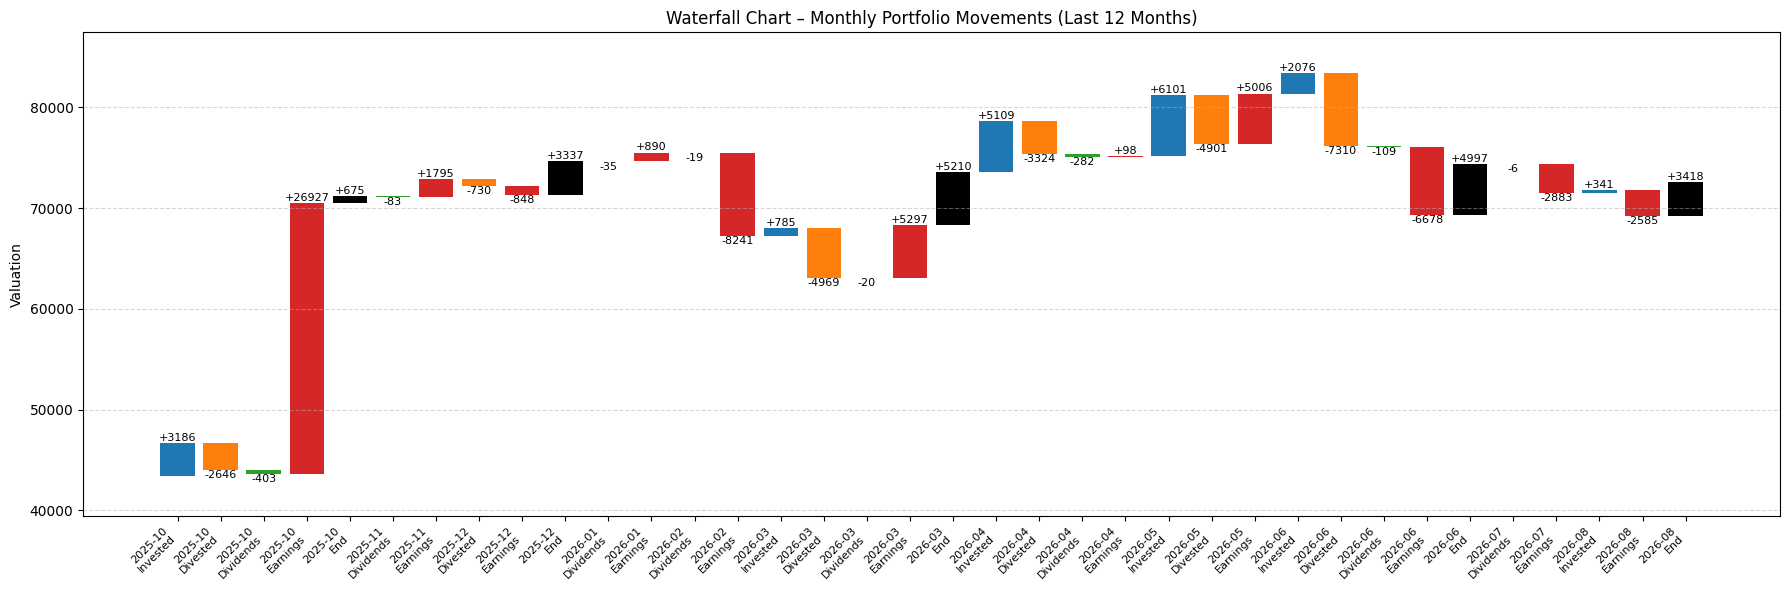

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

monthly_df = earnings_df.copy()
monthly_df['month'] = monthly_df['source_date'].dt.to_period('M')
monthly_df = monthly_df.groupby('month').agg({
    'valuacion': 'sum',
    'delta_invested': 'sum',
    'delta_sold': 'sum',
    'delta_dividends': 'sum',
    'earning': 'sum'
}).reset_index()

# Sort by month to ensure correct shift operation
monthly_df = monthly_df.sort_values('month')

# Calculate previous month's total valuation
monthly_df['prev_valuacion_portfolio'] = monthly_df['valuacion'].shift(1)

# Calculate monthly portfolio return
# Monthly Return = Earning / Beginning_Portfolio_Value
# We use 'earning' as it already accounts for (Ending_Val - Beginning_Val - Net_Contributions)
monthly_df['portfolio_monthly_return'] = monthly_df['earning'] / monthly_df['prev_valuacion_portfolio']

# Filter for the last 12 months (after calculating previous month's valuation)
monthly_df = monthly_df.tail(12)

monthly_df['month_str'] = monthly_df['month'].astype(str)

# Define colors
bar_colors = {
    'Invested': '#1f77b4',
    'Divested': '#ff7f0e',
    'Dividends': '#2ca02c',
    'Earnings': '#d62728',
    'Valuation': '#555555',
    'End': '#000000',
}

positions, labels, heights, bottoms, colors = [], [], [], [], []
curr_pos = 0
cumulative = 0

# Build waterfall bars (skipping first full valuation bar)
for idx, row in monthly_df.iterrows():
    month = row['month_str']
    if idx == monthly_df.index[0]: # Check if it's the very first row of the filtered DataFrame
        cumulative = row['valuacion']
        continue

    steps = [
        ('Invested', row['delta_invested']),
        ('Divested', -row['delta_sold']),
        ('Dividends', -row['delta_dividends']),
        ('Earnings', row['earning']),
    ]

    for label, value in steps:
        if abs(value) < 1e-6:
            continue  # Skip zero entries

        labels.append(f"{month}\n{label}")
        heights.append(value)
        bottoms.append(cumulative)
        colors.append(bar_colors[label])
        positions.append(curr_pos)
        cumulative += value
        curr_pos += 1

    end_val = row['valuacion']
    end_delta = end_val - cumulative
    if abs(end_delta) >= 1e-6:
        labels.append(f"{month}\nEnd")
        heights.append(end_delta)
        bottoms.append(cumulative)
        colors.append(bar_colors['End'])
        positions.append(curr_pos)
        cumulative = end_val
        curr_pos += 1

# Create the chart with dynamic width
fig_width = max(12, 0.5 * len(positions))
fig, ax = plt.subplots(figsize=(fig_width, 6))

# Plot bars
ax.bar(positions, heights, bottom=bottoms, color=colors)

# Add value labels with smart vertical offset
for pos, h, b in zip(positions, heights, bottoms):
    val = b + h
    va = 'bottom' if h >= 0 else 'top'
    offset = 5 if h >= 0 else -8
    ax.text(pos, val + offset, f"{h:+.0f}", ha='center', va=va, fontsize=8, color='black')

# Restore full labels (month + component)
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)

# Center chart around data
min_y = min(bottoms[i] + (heights[i] if heights[i] < 0 else 0) for i in range(len(heights)))
max_y = max(bottoms[i] + (heights[i] if heights[i] > 0 else 0) for i in range(len(heights)))
padding = (max_y - min_y) * 0.1
ax.set_ylim(min_y - padding, max_y + padding)

# Horizontal line at zero
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

# Final polish
ax.set_ylabel('Valuation')
ax.set_title('Waterfall Chart – Monthly Portfolio Movements (Last 12 Months)')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

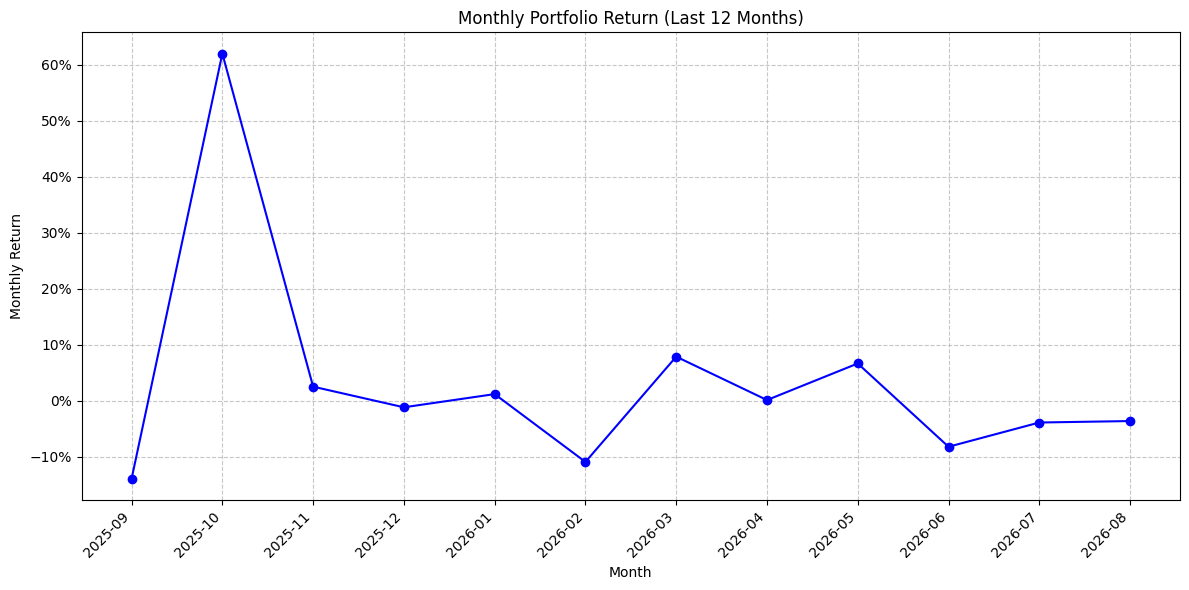

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Create the line chart for monthly portfolio return
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(monthly_df['month_str'], monthly_df['portfolio_monthly_return'], marker='o', linestyle='-', color='blue')

ax.set_title('Monthly Portfolio Return (Last 12 Months)')
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Return')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

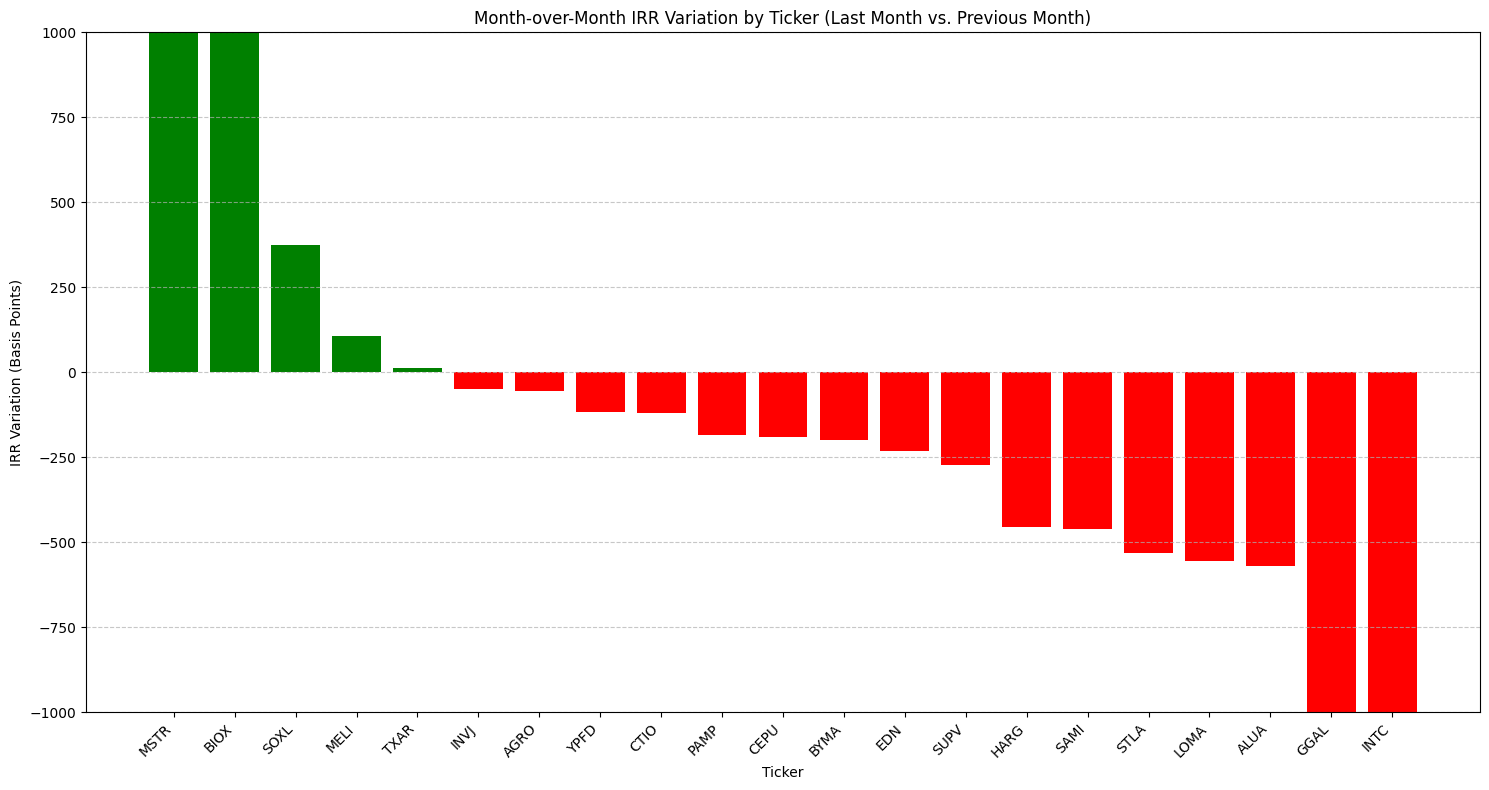

In [ ]:
import matplotlib.pyplot as plt

# Ensure all_data has the correct data types and is sorted
# (It should already be from cell drAQNjCXUtxD and xPkD7HqaU8Q4, but re-sorting for safety)
# Use all_data as it contains the 'tir' column directly
ticker_monthly_data = all_data.sort_values(by=['ticker', 'month'])

# Calculate the previous month's tir for each ticker
ticker_monthly_data['prev_tir'] = ticker_monthly_data.groupby('ticker')['tir'].shift(1)

# Filter to get only the latest month for each ticker that has a previous month's data
latest_month_variations = ticker_monthly_data.dropna(subset=['prev_tir']).groupby('ticker').tail(1).copy()

# --- NEW: Filter to include only tickers present in the last month's data ---
# Define last_month_df
last_date = earnings_df['source_date'].max()
last_month = last_date.to_period('M')
last_month_df = earnings_df[earnings_df['source_date'].dt.to_period('M') == last_month].copy()

# Get tickers from last_month_df
last_month_tickers = last_month_df['ticker'].unique()
# Filter latest_month_variations
latest_month_variations = latest_month_variations[latest_month_variations['ticker'].isin(last_month_tickers)]
# --- END NEW FILTERING ---

# Calculate the IRR variation in basis points (IRR_t - IRR_t-1) * 10000
latest_month_variations['irr_variation_bp'] = (latest_month_variations['tir'] - latest_month_variations['prev_tir']) * 10000

# Sort in descending order for the chart
latest_month_variations = latest_month_variations.sort_values(by='irr_variation_bp', ascending=False)

# Create the bar chart
fig, ax = plt.subplots(figsize=(15, 8))

# Define colors: green for positive, red for negative
colors = ['green' if x >= 0 else 'red' for x in latest_month_variations['irr_variation_bp']]

ax.bar(latest_month_variations['ticker'], latest_month_variations['irr_variation_bp'], color=colors)

ax.set_title('Month-over-Month IRR Variation by Ticker (Last Month vs. Previous Month)')
ax.set_xlabel('Ticker')
ax.set_ylabel('IRR Variation (Basis Points)')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
ax.set_ylim(-1000, 1000) # Set y-axis limits to +/- 1000 basis points
plt.tight_layout()
plt.show()

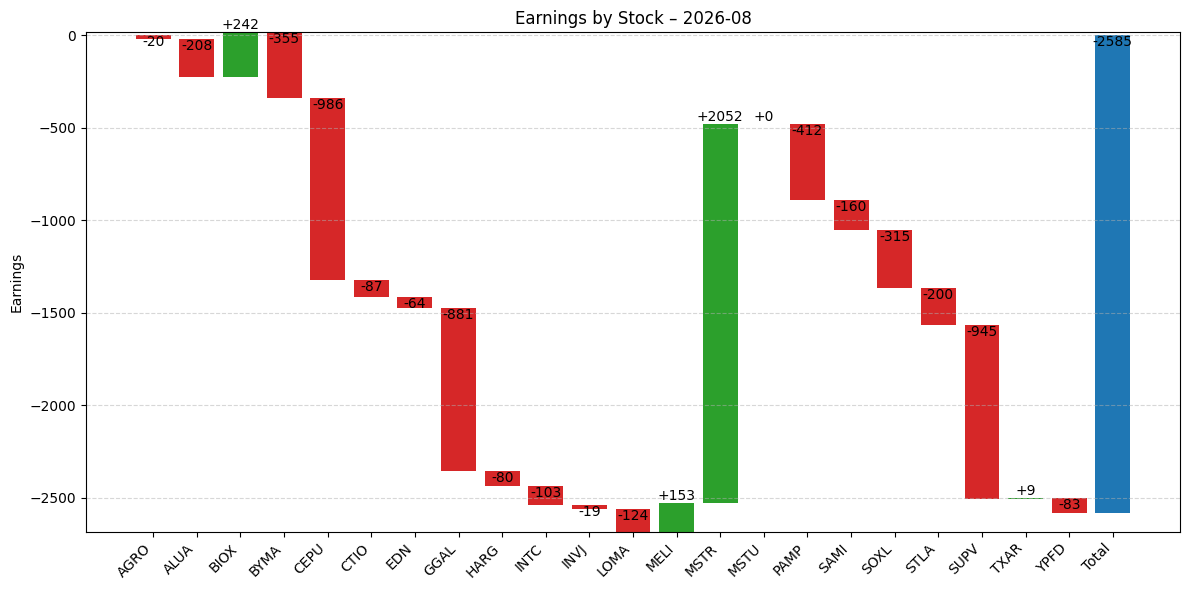

In [ ]:
# Filter earnings for last month
last_date = earnings_df['source_date'].max()
last_month = last_date.to_period('M')#'2025-03'

last_month_df = earnings_df[earnings_df['source_date'].dt.to_period('M') == last_month].copy()

# Group earnings by stock
earnings_by_stock = last_month_df.groupby(first_col)['earning'].sum().reset_index()

# Build data for waterfall
labels = earnings_by_stock[first_col].tolist()
values = earnings_by_stock['earning'].tolist()

# Add final total bar
labels.append('Total')
values.append(sum(values))

# Calculate bottoms for waterfall effect
bottoms = [0]
for val in values[:-1]:
    bottoms.append(bottoms[-1] + val)

# Plot waterfall
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in values[:-1]] + ['#1f77b4']

ax.bar(range(len(values)), values, bottom=bottoms[:-1] + [0], color=colors)

# Add value annotations
for i, (v, b) in enumerate(zip(values, bottoms[:-1] + [0])):
    y = b + v if v >= 0 else b
    ax.text(i, y, f'{v:+.0f}', ha='center', va='bottom' if v >= 0 else 'top')

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Earnings')
ax.set_title(f'Earnings by Stock – {str(last_month)}')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


#Empieza el Analisis por Curva

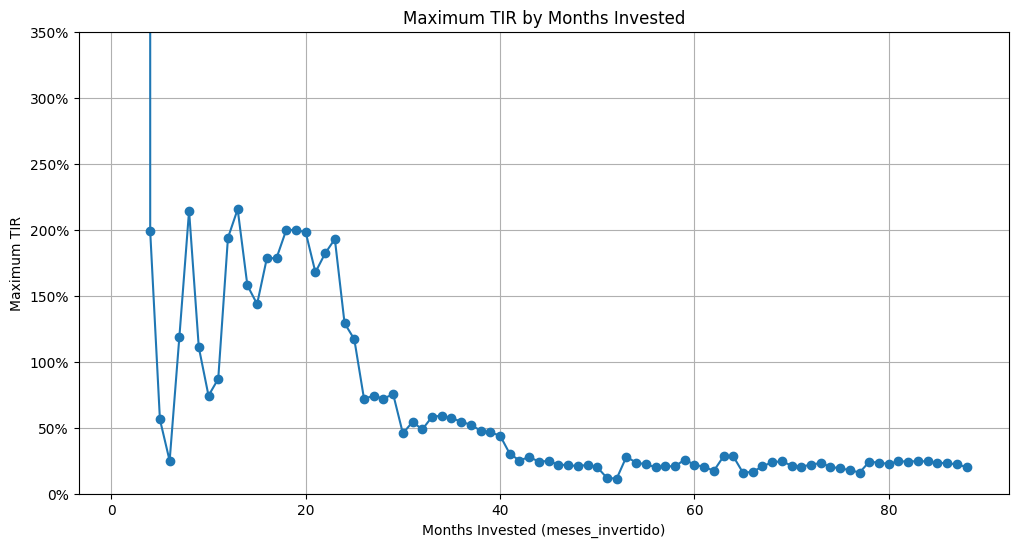

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

all_data['tir'] = pd.to_numeric(all_data['tir'], errors='coerce')
max_tir_by_meses = all_data.groupby('meses_invertido')  ['tir'].max().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(max_tir_by_meses['meses_invertido'], max_tir_by_meses['tir'], marker='o')
plt.title('Maximum TIR by Months Invested')
plt.xlabel('Months Invested (meses_invertido)')
plt.ylabel('Maximum TIR')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.ylim(0, 3.5) # Set y-axis limits from 0 to 1 (0% to 100%)
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

def power_law_func(x, a, b, c):
    """
    Calculates the power law curve model: y = a * x^b + c.

    Args:
        x (array-like): The independent variable.
        a (float): The scaling factor.
        b (float): The exponent.
        c (float): The offset.

    Returns:
        array-like: The calculated y values based on the power law model.
    """
    return a * np.power(x, b) + c

print("Power law function 'power_law_func' defined successfully.")

Power law function 'power_law_func' defined successfully.


In [ ]:
from scipy.optimize import curve_fit

# Filter out 'tir' values greater than 10.0 (1000%) as requested by the user
filtered_max_tir_by_meses = max_tir_by_meses[max_tir_by_meses['tir'] <= 100.0]

# Extract x and y data from the filtered DataFrame
x_data = filtered_max_tir_by_meses['meses_invertido']
y_data = filtered_max_tir_by_meses['tir']

# Set initial guess for parameters (a, b, c)
# Based on the data, TIR starts high and decreases, flattening out.
# 'c' (offset) should be the long-term value, around 0.15-0.2 (15-20%).
# 'b' (exponent) should be negative for a decaying curve.
# 'a' (scaling factor) needs to be positive to capture the initial higher values.
p0 = [1.0, -0.5, 0.2]  # More reasonable initial guesses

# Set bounds for the parameters to guide the fit
# a: positive, b: negative, c: positive (asymptotic TIR)
bounds = ([0.001, -3.0, 0.001], [10.0, -0.01, 1.0])

# Fit the power law function to the data with bounds
popt_power, pcov_power = curve_fit(power_law_func, x_data, y_data, p0=p0, bounds=bounds, maxfev=5000)

# Print the optimal parameters
print(f"Optimal parameters for Power Law: a={popt_power[0]:.4f}, b={popt_power[1]:.4f}, c={popt_power[2]:.4f}")

Optimal parameters for Power Law: a=4.5621, b=-0.5683, c=0.0010


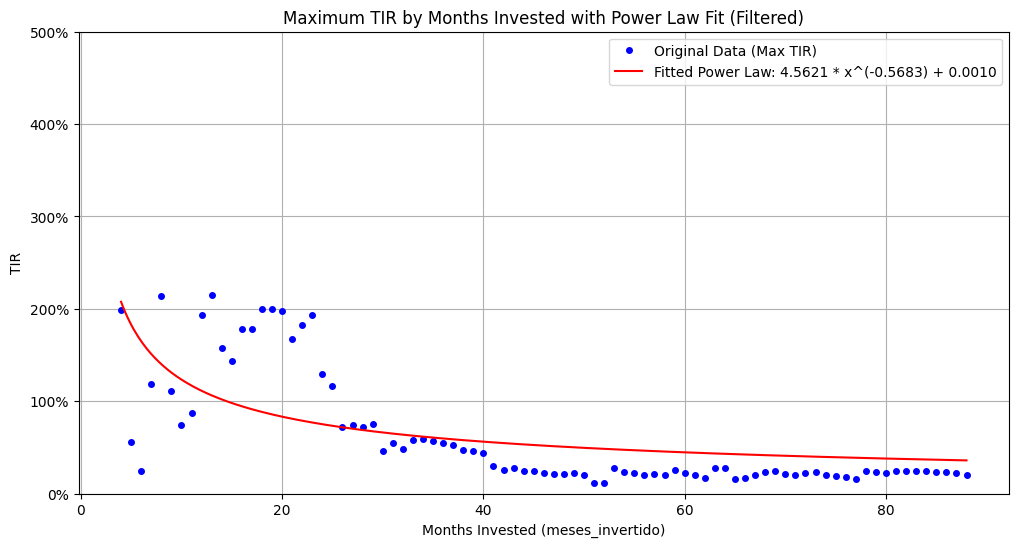

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np # Added numpy import

# Generate y-values for the fitted curve using the optimal parameters
x_fit_power = np.linspace(x_data.min(), x_data.max(), 400)
y_fit_power = power_law_func(x_fit_power, *popt_power)

plt.figure(figsize=(12, 6))

# Plot original data points (filtered)
plt.plot(x_data, y_data, 'o', label='Original Data (Max TIR)', markersize=4, color='blue')

# Plot the fitted power law curve
plt.plot(x_fit_power, y_fit_power, label=f'Fitted Power Law: {popt_power[0]:.4f} * x^({popt_power[1]:.4f}) + {popt_power[2]:.4f}', color='red')

plt.title('Maximum TIR by Months Invested with Power Law Fit (Filtered)')
plt.xlabel('Months Invested (meses_invertido)')
plt.ylabel('TIR')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.ylim(0, 5.0) # Set y-axis limits from 0% to 200%
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
max_tir_by_meses

,meses_invertido,tir
0,1,6685.242334
1,2,145.689768
2,3,2533.204923
3,4,1.986116
4,5,0.561303
...,...,...
83,84,0.243527
84,85,0.233495
85,86,0.230549
86,87,0.221200


In [ ]:
# Get the latest valuation for each ticker
latest_valuations = all_data.loc[all_data.groupby('ticker')['source_date'].idxmax(), ['ticker', 'valuacion']]

# Sort by valuation and get the top 10 tickers
top_10_tickers = latest_valuations.nlargest(10, 'valuacion')['ticker'].tolist()

# Filter the original DataFrame to include only these top 10 tickers
all_data_top_10 = all_data[all_data['ticker'].isin(top_10_tickers)]

print("Top 10 tickers by latest valuation:")
print(top_10_tickers)

Top 10 tickers by latest valuation:
['SUPV', 'MSTR', 'CEPU', 'MELI', 'GGAL', 'PAMP', 'YPFD', 'MSTU', 'EDN', 'STLA']


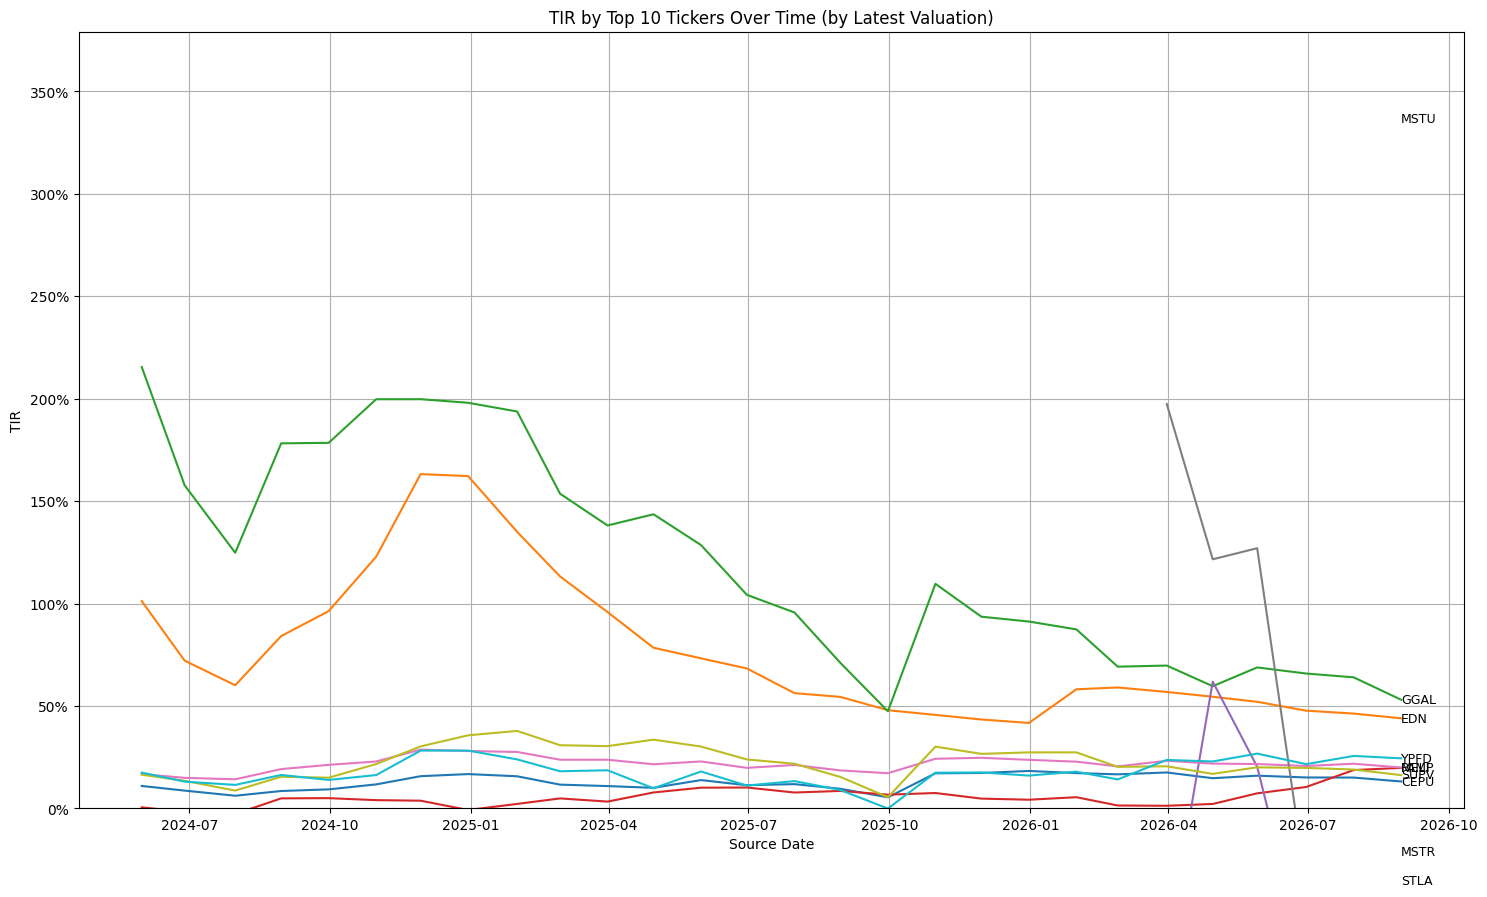

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np

plt.figure(figsize=(15, 9)) # Increased figure height

# Get unique tickers from the filtered data
unique_tickers_top_10 = all_data_top_10['ticker'].unique()

# Calculate dynamic y-axis limits
min_tir = all_data_top_10['tir'].min()
max_tir = all_data_top_10['tir'].max()

# Add a small buffer for better visualization, ensuring y_min doesn't go below 0
buffer = (max_tir - min_tir) * 0.1
if buffer == 0: # Handle cases where all TIRs are the same or very close
    buffer = 0.05 # A small default buffer if data range is tiny
y_min = max(0, min_tir - buffer)
y_max = max_tir + buffer

for ticker_val in unique_tickers_top_10:
    # Filter data for the current ticker from the top 10
    ticker_df = all_data_top_10[all_data_top_10['ticker'] == ticker_val].sort_values(by='source_date')
    # Plot source_date vs tir for the current ticker
    plt.plot(ticker_df['source_date'], ticker_df['tir'], label=ticker_val)

    # Get the last data point for annotation
    if not ticker_df.empty:
        last_date = ticker_df['source_date'].iloc[-1]
        last_tir = ticker_df['tir'].iloc[-1]
        plt.text(last_date, last_tir, ticker_val, fontsize=9, verticalalignment='center')

plt.title('TIR by Top 10 Tickers Over Time (by Latest Valuation)')
plt.xlabel('Source Date')
plt.ylabel('TIR')
plt.ylim(y_min, y_max) # Dynamically set y-axis limits
plt.gca().yaxis.set_major_formatter(PercentFormatter(1)) # Format y-axis as percentage
plt.grid(True)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Removed legend
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import r2_score

# Predict y values using the fitted power law function
y_predicted_power = power_law_func(x_data, *popt_power)

# Calculate R-squared
r_squared_power = r2_score(y_data, y_predicted_power)

print(f"R-squared for Power Law Fit: {r_squared_power:.4f}")

R-squared for Power Law Fit: 0.4191


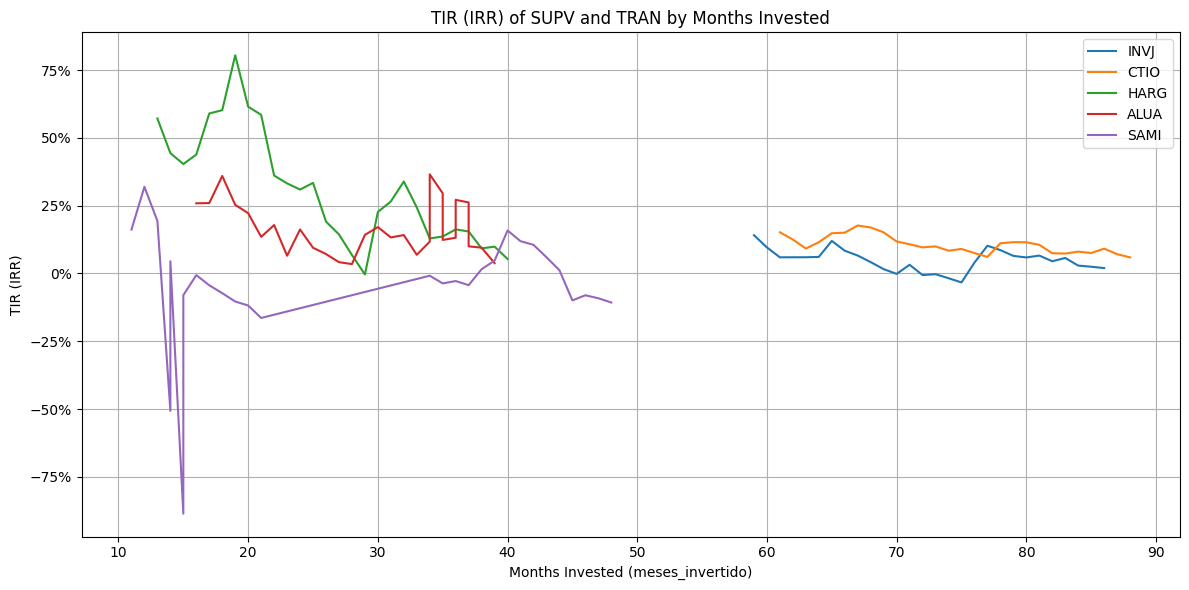

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Filter for SUPV and TRAN tickers
selected_tickers = ['INVJ'
,'CTIO','HARG','ALUA','SAMI'
                    # ,'VIST','MELI','LOMA'
# ,'SUPV','BYMA'
]
filtered_data = all_data[all_data['ticker'].isin(selected_tickers)].copy()

plt.figure(figsize=(12, 6))

for ticker_val in selected_tickers:
    ticker_df = filtered_data[filtered_data['ticker'] == ticker_val].sort_values(by='meses_invertido') # Changed sorting key
    plt.plot(ticker_df['meses_invertido'], ticker_df['tir'], label=ticker_val) # Changed x-axis to meses_invertido

plt.title('TIR (IRR) of SUPV and TRAN by Months Invested')
plt.xlabel('Months Invested (meses_invertido)') # Changed x-axis label
plt.ylabel('TIR (IRR)')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

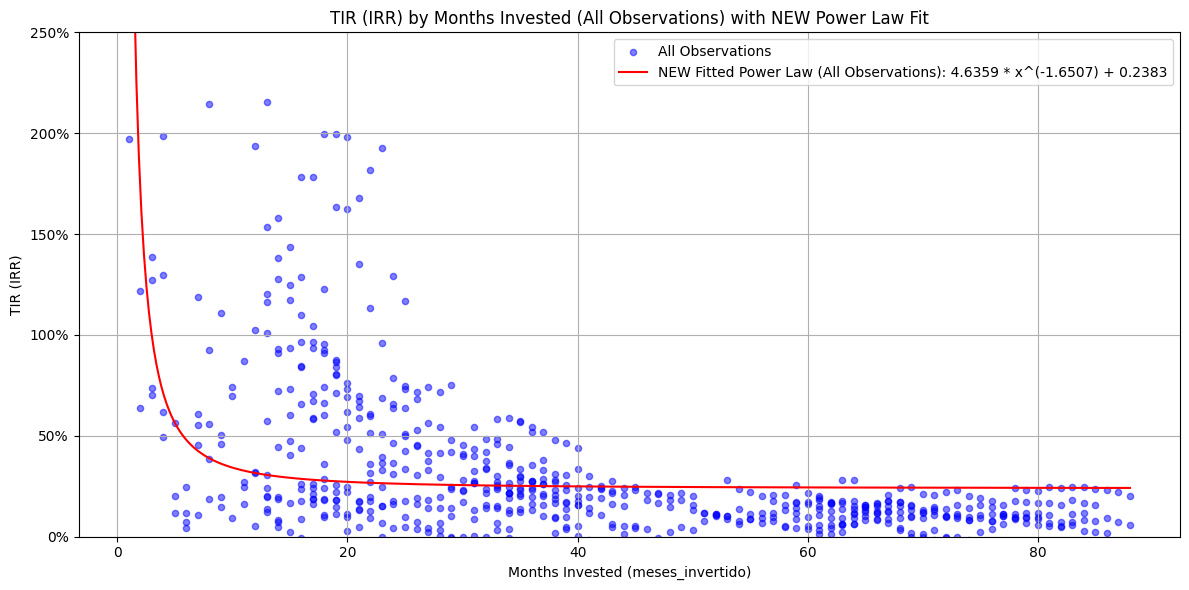

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Define power_law_func here again to ensure it's available
def power_law_func(x, a, b, c):
    return a * np.power(x, b) + c

# --- Code from new_fit_data_prep (prepended to fix NameError) ---
# Prepare data for the new fit using all observations from 'all_data'
# Filter out 'tir' values greater than 10.0 (1000%) as they are likely outliers
# Ensure 'meses_invertido' and 'tir' columns are clean and numerical
filtered_all_data_for_new_fit = all_data.copy()
filtered_all_data_for_new_fit['tir'] = pd.to_numeric(filtered_all_data_for_new_fit['tir'], errors='coerce')
filtered_all_data_for_new_fit = filtered_all_data_for_new_fit.dropna(subset=['meses_invertido', 'tir'])
# We'll use a slightly wider upper bound for filtering all data to capture more points if needed, e.g., 20.0 (2000%)
# The previous fit was on max TIR, which had very high values for low meses_invertido.
# For individual observations, we expect lower outliers but still need to manage extreme ones.
filtered_all_data_for_new_fit = filtered_all_data_for_new_fit[filtered_all_data_for_new_fit['tir'] <= 20.0]

x_data_full = filtered_all_data_for_new_fit['meses_invertido']
y_data_full = filtered_all_data_for_new_fit['tir']

# Set initial guess for parameters (a, b, c) for the new fit
p0_full = [1.0, -0.5, 0.2]  # Initial guesses

# Set bounds for the parameters for the new fit
bounds_full = ([0.001, -3.0, 0.001], [50.0, -0.001, 1.0]) # Adjusted upper bound for 'a' to allow for higher initial TIRs

# Fit the power law function to all data points with bounds
popt_power_full, pcov_power_full = curve_fit(power_law_func, x_data_full, y_data_full, p0=p0_full, bounds=bounds_full, maxfev=5000)
# --- End of prepended code ---

plt.figure(figsize=(12, 6))

# Create a scatter plot for all observations
plt.scatter(x_data_full, y_data_full, alpha=0.5, s=20, color='blue', label='All Observations')

# Generate y-values for the new fitted power law curve using the optimal parameters from popt_power_full
x_fit_full = np.linspace(x_data_full.min(), x_data_full.max(), 400)
y_fit_full = power_law_func(x_fit_full, *popt_power_full)

# Plot the new fitted power law curve on the scatter plot
plt.plot(x_fit_full, y_fit_full, color='red', label=f'NEW Fitted Power Law (All Observations): {popt_power_full[0]:.4f} * x^({popt_power_full[1]:.4f}) + {popt_power_full[2]:.4f}')

plt.title('TIR (IRR) by Months Invested (All Observations) with NEW Power Law Fit')
plt.xlabel('Months Invested (meses_invertido)')
plt.ylabel('TIR (IRR)')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.ylim(0, 2.5) # Adjusted y-axis limit to 250%
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import r2_score

# Predict y values using the new fitted power law function (popt_power_full)
y_predicted_power_full = power_law_func(x_data_full, *popt_power_full)

# Calculate R-squared for the new fit
r_squared_power_full = r2_score(y_data_full, y_predicted_power_full)

print(f"R-squared for NEW Power Law Fit (All Observations): {r_squared_power_full:.4f}")

R-squared for NEW Power Law Fit (All Observations): 0.2951
